## M1 조 송경섭 프로젝트
## 제목 : 택시 이용 내역 데이터

### 1. 결측치 판단 및 처리  
             ; 확인 후 결측 행 삭제

In [44]:
# 1) 원본 데이터 불러오기 

import pandas as pd

pd.read_csv('trip_KS.csv')
data = pd.read_csv('trip_KS.csv')
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22701 non-null  str    
 1   tpep_pickup_datetime   22701 non-null  str    
 2   tpep_dropoff_datetime  22701 non-null  str    
 3   payment_method         22701 non-null  str    
 4   passenger_count        22701 non-null  int64  
 5   trip_distance          22701 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22701 non-null  float64
 8   tolls_amount           22701 non-null  float64
dtypes: float64(4), int64(1), str(4)
memory usage: 1.6 MB


In [45]:
# 2) 결측치 확인 : fare_amount 3개 

data.isna().sum()

passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              3
tip_amount               0
tolls_amount             0
dtype: int64

In [46]:
# 3) 결측치 상세 확인용 내역 출력

data[data['fare_amount'].isna()]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
52,Benjamin Johnson,04/04/2017 4:22:03 PM,04/04/2017 4:35:30 PM,Cash,1,2.20,NaN,0.0,0.00
189,Maria Ibarra,08/21/2017 12:40:25 PM,08/21/2017 1:12:31 PM,Debit Card,3,15.20,NaN,5.0,0.00
244,Tina Avila,08/09/2017 8:32:09 AM,08/09/2017 9:31:11 AM,Cash,1,15.89,NaN,10.0,5.76


In [55]:
# 4) fare_amount 결측치가 있는 행 제거 및 결과 확인 

data_wo_null = data.dropna(subset=["fare_amount"]).copy()

print("원본 :", data.shape)
print("결측치 제거 :", data_wo_null.shape)
print("결측치 개수 :\n", data_wo_null.isna().sum())
print("\nfare_amount 결측치 개수:", data_wo_null["fare_amount"].isna().sum())

# 5) 결측치 제거 후 'data_wo_null.csv' 파일 이름으로 저장 (인덱스는 파일에 저장하지 않음) 
data_wo_null.to_csv("data_wo_null.csv", index=False, encoding="utf-8-sig")
print("저장 완료: data_wo_null.csv")


원본 : (22701, 9)
결측치 제거 : (22698, 9)
결측치 개수 :
 passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              0
tip_amount               0
tolls_amount             0
dtype: int64

fare_amount 결측치 개수: 0
저장 완료: data_wo_null.csv


In [48]:
# 6) 결측치 제거 후 내용 재확인 

import pandas as pd
pd.read_csv('data_wo_null.csv')
data_wo_null.info()
# data.info(data_wo_null.csv)

<class 'pandas.DataFrame'>
Index: 22698 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22698 non-null  str    
 1   tpep_pickup_datetime   22698 non-null  str    
 2   tpep_dropoff_datetime  22698 non-null  str    
 3   payment_method         22698 non-null  str    
 4   passenger_count        22698 non-null  int64  
 5   trip_distance          22698 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22698 non-null  float64
 8   tolls_amount           22698 non-null  float64
dtypes: float64(4), int64(1), str(4)
memory usage: 1.7 MB


### 2. 이상치 판단 및 처리

In [59]:
data_wo_null.describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000
mean,1.643581,2.912318,13.024009,1.835327,0.312302
std,1.304983,3.651335,13.240074,2.800093,1.398775
min,0.000000,0.000000,-120.000000,0.000000,0.000000
25%,1.000000,0.990000,6.500000,0.000000,0.000000
50%,1.000000,1.610000,9.500000,1.350000,0.000000
75%,2.000000,3.060000,14.500000,2.450000,0.000000
max,36.000000,33.960000,999.990000,200.000000,19.100000


<Axes: xlabel='None', ylabel='passenger_count'>

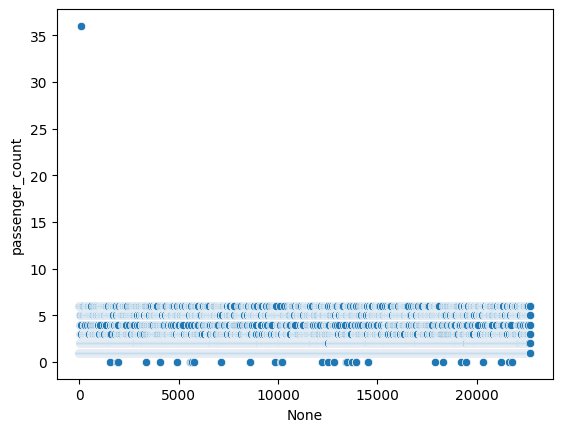

In [84]:
# scatterplot 으로 보기 
# Column 1-1) passenger_count

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['passenger_count'])

In [ ]:
# 1-2) 내림차순으로 정렬하여 세부 내역 확인 :이상치로 판단

data_wo_null['passenger_count'].sort_values(ascending = False).head(5)

64       36
49        6
6489      6
11461     6
753       6
Name: passenger_count, dtype: int64

In [102]:
print("data_wo_null" in globals())


True


In [105]:
# index 64 제거

data_wo_null = data_wo_null.drop(index=64, errors="ignore")
data_wo_null['passenger_count'].sort_values(ascending = False).head(5)
# data_wo_null.head(5)


5970     6
13226    6
13228    6
1248     6
11963    6
Name: passenger_count, dtype: int64

In [104]:
64 in data_wo_null.index


False

<Axes: xlabel='None', ylabel='trip_distance'>

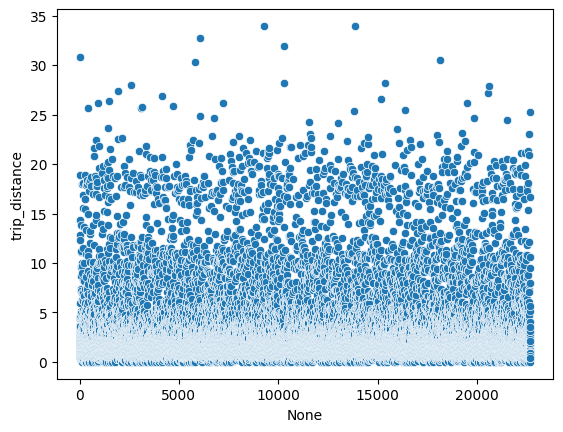

In [ ]:
# scatterplot 으로 보기 
# Column 2-1) trip_distance

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['trip_distance'])

In [ ]:
# 2-2) 내림차순으로 정렬하여 세부 내역 확인 : 이상치 아님으로 판정

data_wo_null['trip_distance'].sort_values(ascending = False).head(10)

9282     33.96
13863    33.92
6066     32.72
10293    31.95
30       30.83
18132    30.50
5794     30.33
15352    28.23
10304    28.20
2594     27.97
Name: trip_distance, dtype: float64

<Axes: xlabel='None', ylabel='fare_amount'>

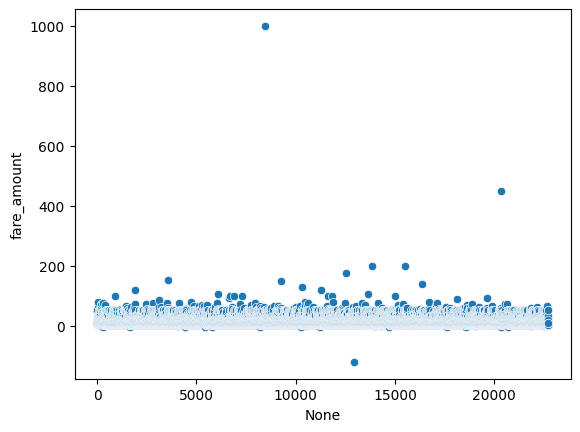

In [ ]:
# scatterplot 으로 보기 
# Column 3-1) fare_amount

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['fare_amount'])

In [ ]:
# 3-2) 내림차순으로 정렬하여 세부 내역 확인 : 이상치이나 그냥 둠

data_wo_null['fare_amount'].sort_values(ascending = False).head(5)

8478     999.99
20314    450.00
13863    200.01
15476    200.00
12513    175.00
Name: fare_amount, dtype: float64

<Axes: xlabel='None', ylabel='tip_amount'>

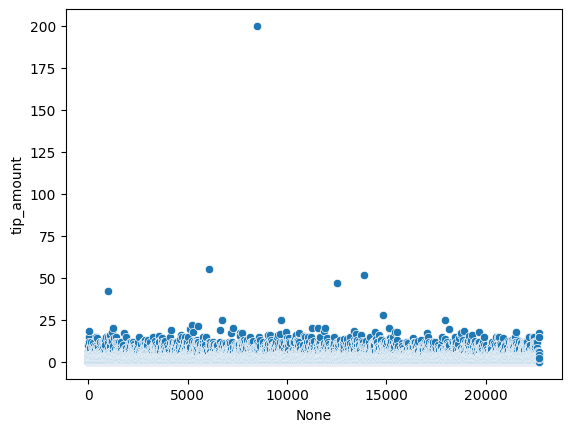

In [ ]:
# scatterplot 으로 보기 
# Column 4-1) tip_amount 

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['tip_amount'])

In [ ]:
# 4-2) 내림차순으로 정렬하여 세부 내역 확인 : 이상치이나 그냥 둠

data_wo_null['tip_amount'].sort_values(ascending = False).head(5)

8478     200.00
6066      55.50
13863     51.64
12513     46.69
986       42.29
Name: tip_amount, dtype: float64

<Axes: xlabel='None', ylabel='tolls_amount'>

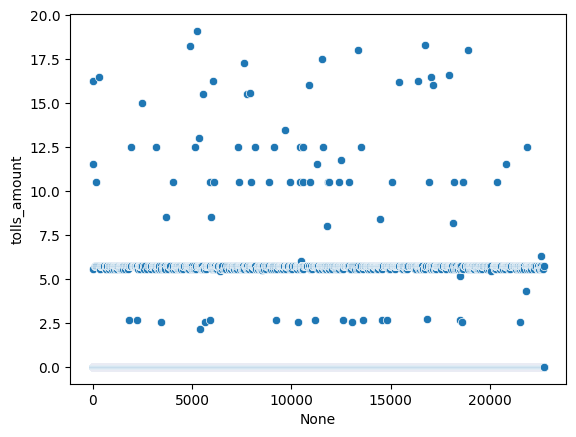

In [90]:
# scatterplot 으로 보기 
# Column 5-1) tolls_amount 

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['tolls_amount'])

In [ ]:
# 5-2) 내림차순으로 정렬하여 세부 내역 확인 : 이상치 아님

data_wo_null['tolls_amount'].sort_values(ascending = False).head(10)

5273     19.10
16707    18.28
4887     18.26
18890    18.00
13361    18.00
11562    17.50
7629     17.28
17961    16.62
318      16.50
17048    16.50
Name: tolls_amount, dtype: float64

In [62]:
# 오름차순으로 정렬

data_wo_null['fare_amount'].sort_values().tail(30)

4717      78.00
16707     79.50
11865     80.00
30        80.00
10446     80.00
4744      80.84
3140      85.50
18132     90.50
6628      93.75
19631     94.20
6880      98.50
11841     99.00
11610     99.50
7283     100.00
14997    100.00
910      100.00
6710     100.00
13623    105.00
6066     107.00
1930     120.00
11271    120.00
10293    131.00
16381    140.00
9282     150.00
3584     152.00
12513    175.00
15476    200.00
13863    200.01
20314    450.00
8478     999.99
Name: fare_amount, dtype: float64

In [63]:
# 내림차순으로 정렬

data_wo_null['fare_amount'].sort_values(ascending = False).head(30)

8478     999.99
20314    450.00
13863    200.01
15476    200.00
12513    175.00
3584     152.00
9282     150.00
16381    140.00
10293    131.00
11271    120.00
1930     120.00
6066     107.00
13623    105.00
14997    100.00
6710     100.00
7283     100.00
910      100.00
11610     99.50
11841     99.00
6880      98.50
19631     94.20
6628      93.75
18132     90.50
3140      85.50
4744      80.84
30        80.00
11865     80.00
10446     80.00
16707     79.50
4717      78.00
Name: fare_amount, dtype: float64

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

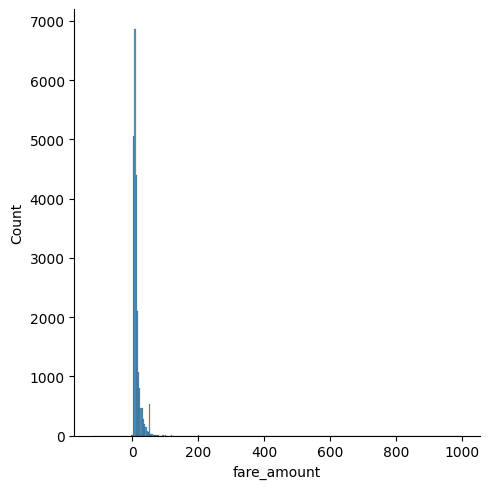

In [67]:
sns.displot(data['fare_amount'])

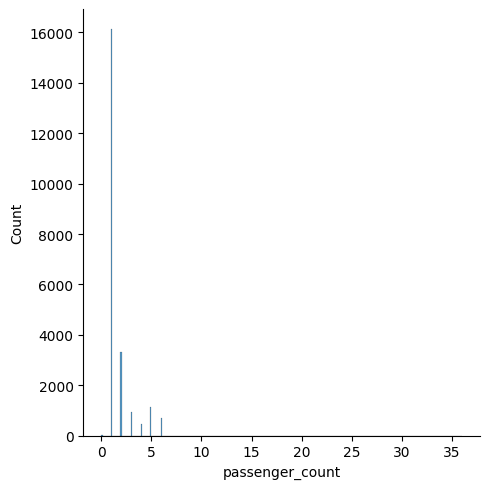

In [69]:
sns.displot(data['passenger_count'])